# Autoencoder in PyTorch

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split

In [186]:
# load simulation data
Eb = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_basal_grid.mat")['enthalpy_basal_grid']
Em = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_avg_grid.mat")['enthalpy_avg_grid']

Eb = np.array(Eb)
Em = np.array(Em)

transformer_Eb = sklearn.preprocessing.StandardScaler()
transformer_Em = sklearn.preprocessing.StandardScaler()

Eb_standard = transformer_Eb.fit_transform(Eb.reshape(-1, 1))
Eb_standard = Eb_standard.reshape(int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), Eb.shape[2])

Em_standard = transformer_Em.fit_transform(Em.reshape(-1, 1))
Em_standard = Em_standard.reshape(int(np.sqrt(np.shape(Em_standard)[0]/Em.shape[2])), int(np.sqrt(np.shape(Em_standard)[0]/Em.shape[2])), Em.shape[2])

Em_standard = np.moveaxis(Em_standard, -1, 0)
Em_standard = Em_standard[:, np.newaxis, :, :]
Em_standard[np.isnan(Em_standard)] = 0
Em_standard = torch.tensor(Em_standard).float()

Eb_standard = np.moveaxis(Eb_standard, -1, 0)
Eb_standard = Eb_standard[:, np.newaxis, :, :]
Eb_standard[np.isnan(Eb_standard)] = 0
Eb_standard = torch.tensor(Eb_standard).float()

In [198]:
Em_dataset = TensorDataset(Em_standard, Em_standard)

train_size = 200
val_size = int(len(Em_dataset) - train_size)

generator = torch.Generator().manual_seed(42)
Em_train_dataset, Em_val_dataset = random_split(Em_dataset, [train_size, val_size], generator=generator)

Em_train_dataloader = DataLoader(Em_train_dataset, batch_size = 1, shuffle = 1)
Em_val_dataloader = DataLoader(Em_val_dataset, batch_size = 1, shuffle = 1)

In [218]:
class Net(nn.Module):
    def __init__(self):
      super(Net, self).__init__()
      self.encoder = nn.Sequential(
        nn.Conv2d(1, 1, 3, 1),
        nn.ReLU(),
        nn.Conv2d(1, 1, 7, 1),
        nn.ReLU(),
        nn.Flatten(start_dim=1),
        nn.Linear(61504, 128),
        nn.Linear(128, 10),
        nn.Sigmoid()
      )
      self.decoder = nn.Sequential(
        nn.Sigmoid(),
        nn.Linear(10, 128),
        #nn.Unflatten(dim=1),
        nn.Linear(128, 61504),
        nn.Unflatten(dim=1, unflattened_size = (248, 248)),
        nn.ReLU(),
        nn.ConvTranspose2d(1, 1, 7, 1),
        nn.ReLU(),
        nn.ConvTranspose2d(1, 1, 3, 1)
      )
    
    def forward(self, x):
       x = self.encoder(x)
       x = self.decoder(x)
       return x

In [219]:
torch.autograd.set_detect_anomaly(True)

model = Net()
num_epochs = 50
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(num_epochs):
    start = torch.Event(enable_timing=True)
    end = torch.Event(enable_timing=True)

    start.record()

    model.train()
    running_loss = 0.0
    for Em_batch, _ in Em_train_dataloader:
        outputs = model(Em_batch)
        loss = criterion(outputs, Em_batch.squeeze(0))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * Em_batch.size(0)
    
    epoch_loss = running_loss / len(Em_train_dataloader.dataset) 

    end.record()

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")

Epoch [1/50], Loss: 0.2204, time elapsed = 7.28 s
Epoch [2/50], Loss: 0.1534, time elapsed = 7.26 s
Epoch [3/50], Loss: 0.1340, time elapsed = 7.38 s
Epoch [4/50], Loss: 0.1197, time elapsed = 7.28 s
Epoch [5/50], Loss: 0.1088, time elapsed = 7.56 s
Epoch [6/50], Loss: 0.1025, time elapsed = 7.34 s
Epoch [7/50], Loss: 0.0978, time elapsed = 7.25 s
Epoch [8/50], Loss: 0.0936, time elapsed = 7.25 s
Epoch [9/50], Loss: 0.0891, time elapsed = 7.37 s
Epoch [10/50], Loss: 0.0847, time elapsed = 7.34 s
Epoch [11/50], Loss: 0.0800, time elapsed = 7.26 s
Epoch [12/50], Loss: 0.0757, time elapsed = 7.35 s
Epoch [13/50], Loss: 0.0714, time elapsed = 7.26 s
Epoch [14/50], Loss: 0.0672, time elapsed = 7.36 s
Epoch [15/50], Loss: 0.0637, time elapsed = 7.33 s
Epoch [16/50], Loss: 0.0613, time elapsed = 7.31 s
Epoch [17/50], Loss: 0.0596, time elapsed = 7.29 s
Epoch [18/50], Loss: 0.0584, time elapsed = 7.28 s
Epoch [19/50], Loss: 0.0573, time elapsed = 7.35 s
Epoch [20/50], Loss: 0.0564, time elapse

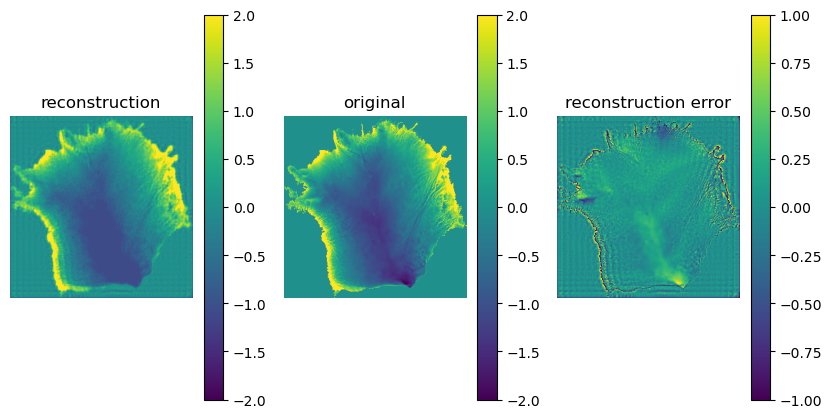

In [247]:
figs, axs = plt.subplots(1, 3, figsize = (10, 5))

im0 = axs[0].imshow(model(Em_val_dataset[0][0]).detach().numpy()[0, :, :], vmin = -2, vmax = 2)
axs[0].invert_yaxis()
axs[0].axis('off')
axs[0].set_title("reconstruction")
plt.colorbar(im0)

im1 = axs[1].imshow(Em_val_dataset[0][1].detach().numpy()[0, :, :], vmin = -2, vmax = 2)
axs[1].invert_yaxis()
axs[1].axis('off')
axs[1].set_title("original")
plt.colorbar(im1)

im2 = axs[2].imshow((model(Em_val_dataset[0][0]) - Em_val_dataset[0][1]).detach().numpy()[0, :, :], vmin = -1, vmax = 1)
axs[2].invert_yaxis()
axs[2].axis('off')
axs[2].set_title("reconstruction error")
plt.colorbar(im2)